## Load data

In [1]:
import os 
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

dir_path = "training_data"

data = []
for label in range(10): 
    for file_path in [os.path.join(dir_path, f) for f in os.listdir(dir_path) if ".csv" in f and f"stroke_{label}" in f]: 
        data.append((label, pd.read_csv(file_path, header=None)))

## Apply PCA

In [2]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

data_PCA = []
for label, df in data: 

    # Convert data to a matrix
    coordinates = df.to_numpy()
    
    # Apply weights
    # w = np.array([1.0, 2.0, 0.5])
    # X = X * w

    # Fit PCA
    # X_pca = X[:, [1, 0, 2]]
    coordinates_pca = PCA(n_components=3).fit_transform(coordinates) 

    # Apply inverse weights
    # X_pca /= (-np.array(np.sort(-w)))

    # Scale the data to range [0, 1] (min-max-scaling)
    #X_pca_scaled = StandardScaler().fit_transform(X_pca)
    #X_pca_scaled = (X_pca- np.min(X_pca, axis=0))/ (np.max(X_pca) - np.min(X_pca))
    #X_pca_scaled = X_pca - np.mean(X_pca, axis=0) # Center the data 
    data_PCA.append((label, coordinates_pca))

## Convert data to images

20


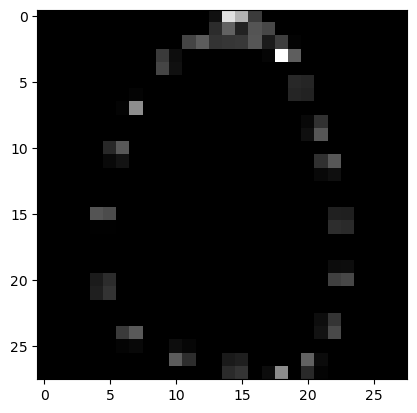

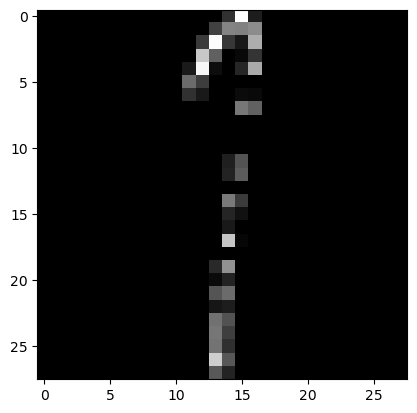

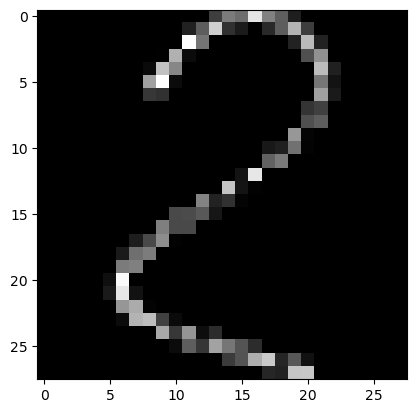

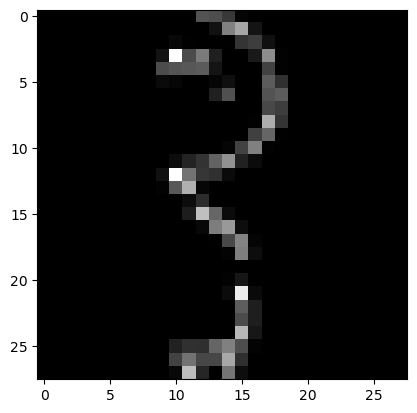

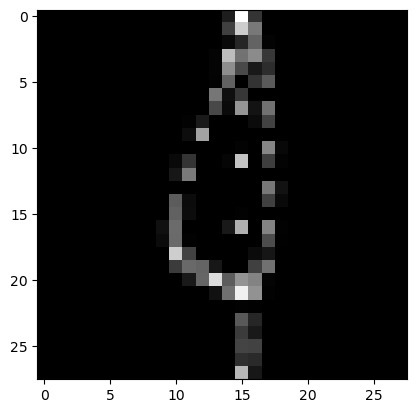

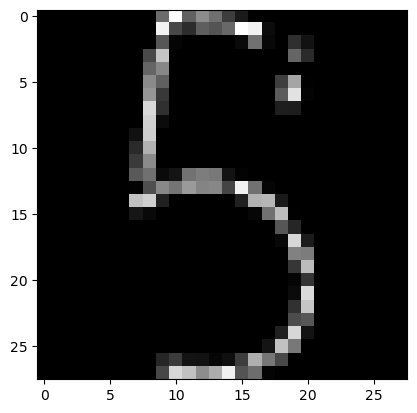

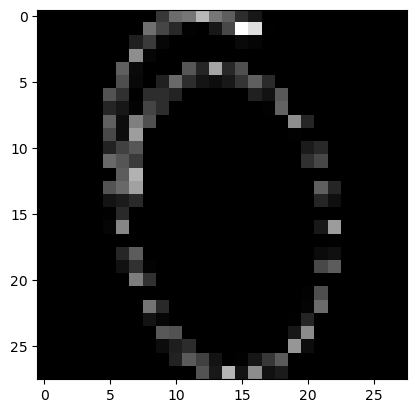

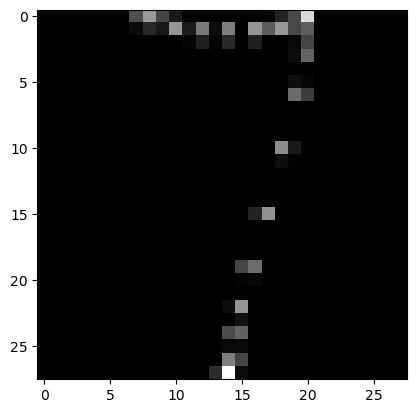

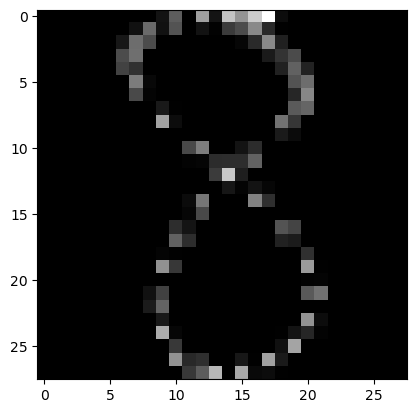

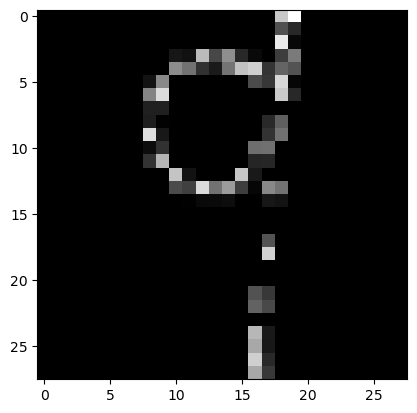

In [3]:
num_samples = sum([len(data_PCA[i]) for i in range(10)])
print(num_samples)

N = 28 # This is image width/height (square "images")
data_images = []

for label, coordinates in data_PCA: 

    # Scale the coordinates
    coordinates = coordinates - (np.min(coordinates, axis=0) + np.max(coordinates, axis=0)) / 2 # Center the sample to 0
    coordinates = coordinates / np.max(np.abs(coordinates)) # Scale to range [-1, 1]
    coordinates = coordinates * ((N-1) / 2) + ((N-1) / 2) # Scale to range [0, N-1]

    # Extract coordinates
    x, y, z = coordinates[:, 1], coordinates[:, 0], 1

    # Convert x, y data to pixels in an image
    image = np.zeros((N, N))
    image[np.floor(y).astype(int), np.floor(x).astype(int)] += z * ((1 - y % 1) * (1 - x % 1))
    image[np.ceil(y).astype(int), np.ceil(x).astype(int)] += z * ((y % 1) * (x % 1))
    image[np.ceil(y).astype(int), np.floor(x).astype(int)] += z * ((1 - x % 1) * (y % 1))
    image[np.floor(y).astype(int), np.ceil(x).astype(int)] += z * ((x % 1) * (1 - y % 1))
    
    # Flip the image (so that it is not upside down) and add it to list
    image = np.flip(image, 0)

    # Add image to list
    data_images.append((label, image))

# Show some images
next_label = 0
for label, image in data_images: 
    if label == next_label: 
        plt.figure()
        plt.imshow(image, cmap='Grays_r')
        next_label += 1

## Stack images and labels to arrays

In [4]:
X = np.stack([image for _, image in data_images])
y = np.array([label for label, _ in data_images])

print(X.shape, y.shape)

(1000, 28, 28) (1000,)
